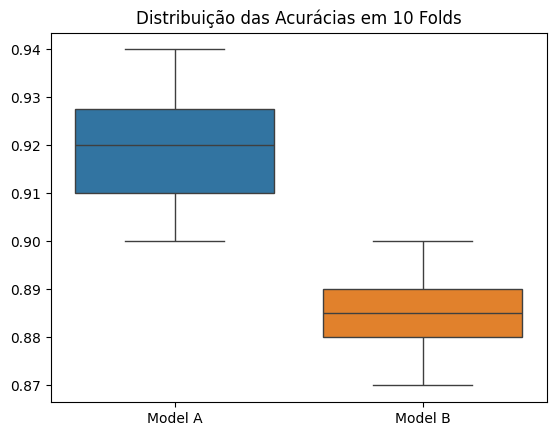

In [4]:
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

# Resultados em 10 folds
model_A = np.array([0.91, 0.90, 0.92, 0.91, 0.93, 0.92, 0.91, 0.93, 0.94, 0.92])
model_B = np.array([0.88, 0.89, 0.87, 0.89, 0.90, 0.88, 0.87, 0.89, 0.88, 0.90])

df = pd.DataFrame({'Model A': model_A, 'Model B': model_B})
sns.boxplot(data=df)
plt.title("Distribuição das Acurácias em 10 Folds")
plt.show()

In [5]:
_, p_A = stats.shapiro(model_A)
_, p_B = stats.shapiro(model_B)
print(f"p-value do Shapiro para o Modelo A: {p_A:.4f}")
print(f"p-value do Shapiro para o Modelo B: {p_B:.4f}")

p-value do Shapiro para o Modelo A: 0.6915
p-value do Shapiro para o Modelo B: 0.2582


In [6]:
_, p_var = stats.levene(model_A, model_B)
print(f"p-value de Levene (homogeneidade de variâncias): {p_var:.4f}")

p-value de Levene (homogeneidade de variâncias): 1.0000


In [7]:
t_stat, p_val = stats.ttest_rel(model_A, model_B)
print(f"t={t_stat:.3f}, p={p_val:.4f}")

t=7.141, p=0.0001


In [8]:
model_C = np.array([0.93, 0.94, 0.92, 0.93, 0.94, 0.95, 0.93, 0.94, 0.92, 0.93])
f_stat, p_val = stats.f_oneway(model_A, model_B, model_C)
print(f"F={f_stat:.3f}, p={p_val:.4f}")

F=52.229, p=0.0000


In [ ]:
w_stat, p_val = stats.wilcoxon(model_A, model_B)print(f"Wilcoxon: W={w_stat:.3f}, p={p_val:.4f}")

Wilcoxon: W=0.000, p=0.0020


In [10]:
u_stat, p_val = stats.mannwhitneyu(model_A, model_B)
print(f"Mann–Whitney U: U={u_stat:.3f}, p={p_val:.4f}")

Mann–Whitney U: U=99.000, p=0.0002


In [11]:
h_stat, p_val = stats.kruskal(model_A, model_B, model_C)
print(f"Kruskal–Wallis: H={h_stat:.3f}, p={p_val:.4f}")

Kruskal–Wallis: H=22.014, p=0.0000


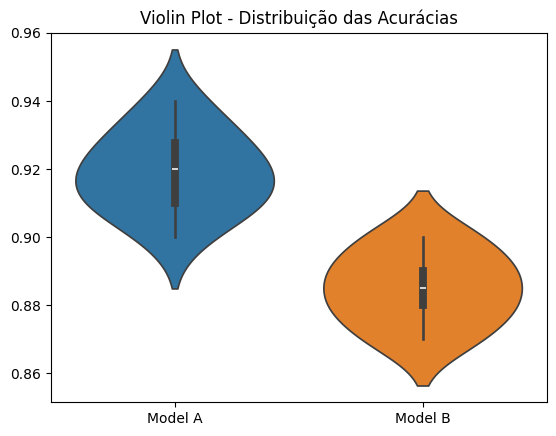

In [17]:
sns.violinplot(data=df)
plt.title("Violin Plot - Distribuição das Acurácias")
plt.show()

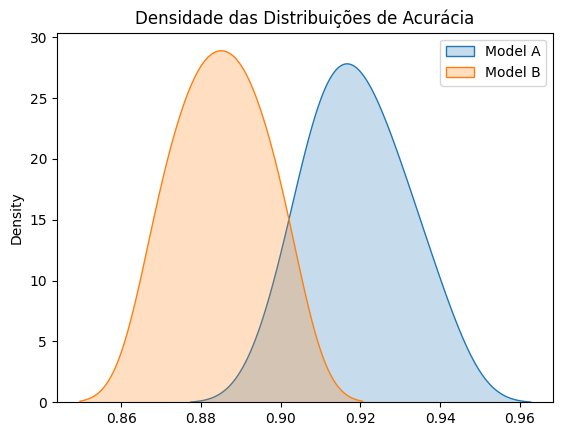

In [16]:
sns.kdeplot(model_A, fill=True, label="Model A")
sns.kdeplot(model_B, fill=True, label="Model B")
plt.legend()
plt.title("Densidade das Distribuições de Acurácia")
plt.show()

In [21]:
import numpy as np
from scipy.stats import shapiro, ttest_rel

# Simulação de acurácias
np.random.seed(42)
model_A = np.random.normal(0.91, 0.01, 10)
model_B = np.random.normal(0.89, 0.01, 10)

# 1. Teste de normalidade
print("Normalidade A:", shapiro(model_A)[-1])
print("Normalidade B:", shapiro(model_B)[-1])

# 2. Teste de comparação pareada
t_stat, p_val = ttest_rel(model_A, model_B)
print(f"Resultado: t={t_stat:.3f}, p={p_val:.4f}")

# 3. Interpretação
if p_val < 0.05:
    print("O modelo A tem desempenho significativamente melhor que o B.")
else:
    print("Não há diferença significativa entre os modelos.")

Normalidade A: 0.26529047692448154
Normalidade B: 0.6770909909669274
Resultado: t=9.295, p=0.0000
O modelo A tem desempenho significativamente melhor que o B.
